# STAGE 3: In-Depth Hyperparameter Tuning (Random Forest & XGBoost)

**Input**: Top 2 models from Stage 2 (Random Forest & XGBoost)

**Goal**: Exhaustive tuning with visualization of parameter effects

**Approach**:
1. Extensive GridSearchCV on both models
2. Visualize how F1-Score changes with key parameters
3. Select single best model with optimal hyperparameters

**Output**: 
- Best tuned model
- Parameter effect visualizations
- Comprehensive tuning results

## Setup and Imports

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import joblib
import warnings
from scipy.stats import randint, uniform, loguniform

warnings.filterwarnings('ignore')

# Create directories
os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)

from evaluate_model import evaluate_model

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

np.random.seed(42)

## Load Data and Top Models List

In [19]:
# Load preprocessed data (same as Stage 2)
train_df = pd.read_csv('../data/train_data_preprocessed.csv')
X = train_df.drop('Revenue', axis=1)
y = train_df['Revenue']

print(f"Data shape: {X.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")

# Setup CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
tuning_results = []

Data shape: (9864, 17)
Class distribution: {0: 8338, 1: 1526}


### Part 1: Random Forest - Extensive Tuning

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=800,          # fix high for stability
    bootstrap=True,
    class_weight='balanced',   # imbalance-aware
    criterion='gini',
    n_jobs=-1,
    random_state=42
)

# Distributions cover space better than enumerating tons of values
param_dist = {
    "max_depth": [None, 10, 15, 20, 30, 40, 50, 60],
    "min_samples_leaf": randint(1, 9),     # 1..8
    "min_samples_split": randint(2, 21),   # 2..20
    "max_features": ["sqrt", "log2", uniform(0.3, 0.5)]  # sqrt/log2 or 0.3–0.8
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=100,                 # << deep pass
    cv=cv,
    scoring='f1',               # we’ll still threshold-tune after picking a model
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=False
)

search.fit(X, y)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params (deep pass): {'max_depth': 60, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 9}
Best CV F1: 0.6803910085146638


In [ ]:
best_rf = search.best_estimator_
print("Best params (deep pass):", search.best_params_)
print("Best CV F1:", search.best_score_)

In [21]:
cvdf = pd.DataFrame(search.cv_results_).sort_values("mean_test_score", ascending=False)
cvdf = cvdf[[
    "rank_test_score","mean_test_score","std_test_score",
    "param_max_depth","param_min_samples_leaf","param_min_samples_split","param_max_features"
]]
cvdf.rename(columns={"mean_test_score":"mean_f1","std_test_score":"std_f1"}, inplace=True)
cvdf.to_csv("rf_randomsearch_100iter.csv", index=False)


### Random Forest: Parameter Effect Visualizations

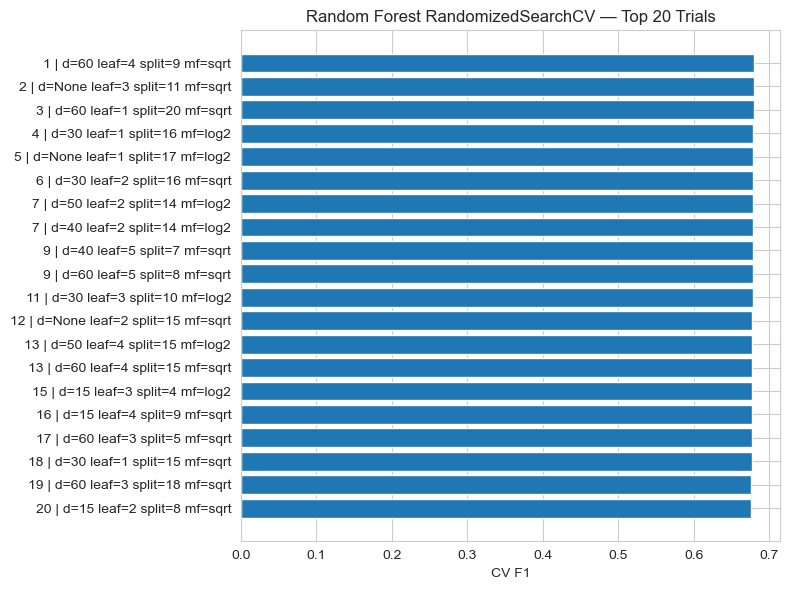

In [22]:
topk = cvdf.head(20)[::-1]  # reverse for horizontal bar
plt.figure(figsize=(8,6))
plt.barh(range(len(topk)), topk["mean_f1"])
plt.yticks(range(len(topk)), [f"{r} | d={d} leaf={leaf} split={spl} mf={mf}"
                              for r,d,leaf,spl,mf in zip(topk["rank_test_score"],
                                                         topk["param_max_depth"],
                                                         topk["param_min_samples_leaf"],
                                                         topk["param_min_samples_split"],
                                                         topk["param_max_features"])])
plt.xlabel("CV F1")
plt.title("Random Forest RandomizedSearchCV — Top 20 Trials")
plt.tight_layout(); plt.show()


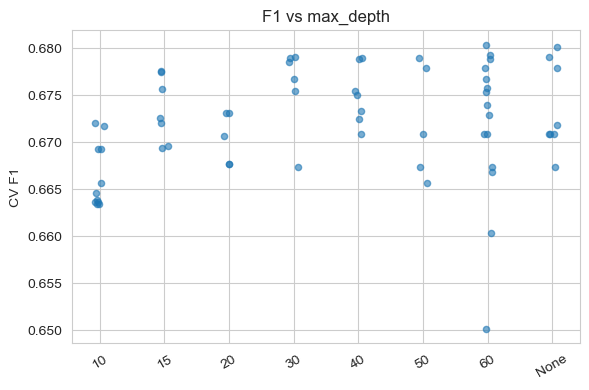

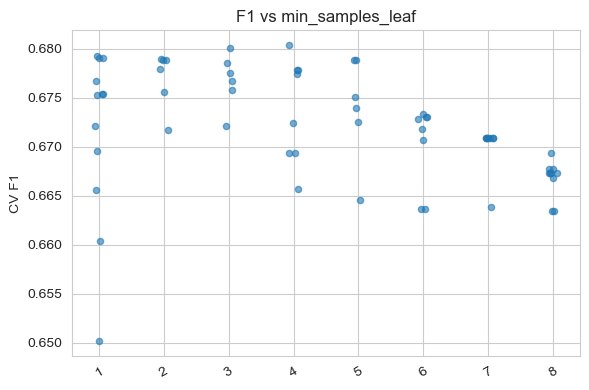

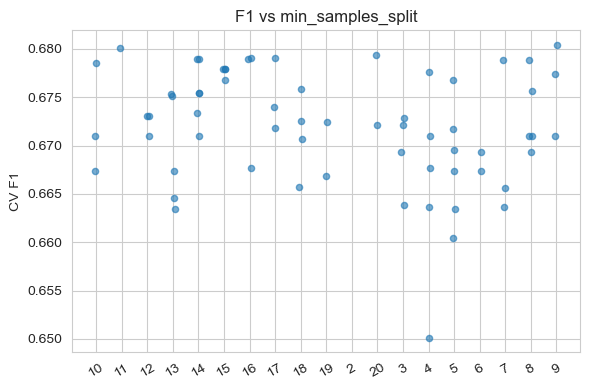

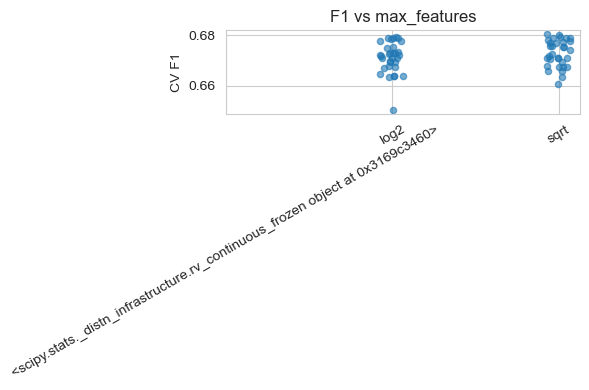

In [23]:
def scatter_param(param):
    plt.figure(figsize=(6,4))
    x = cvdf[f"param_{param}"].astype(str)
    y = cvdf["mean_f1"].values
    # jitter categorical x
    xi = np.arange(len(x))
    # map identical categories to same xi
    cats = {c:i for i,c in enumerate(sorted(x.unique()))}
    xs = x.map(cats).astype(float).values + (np.random.rand(len(x))-0.5)*0.15
    plt.scatter(xs, y, s=20, alpha=0.6)
    plt.xticks(list(cats.values()), list(cats.keys()), rotation=30)
    plt.ylabel("CV F1")
    plt.title(f"F1 vs {param}")
    plt.tight_layout(); plt.show()

for p in ["max_depth","min_samples_leaf","min_samples_split","max_features"]:
    scatter_param(p)


### Part 2: XGBoost - Extensive Tuning

In [ ]:
print("\n" + "="*80)
print("XGBOOST: DEEP RANDOMIZED TUNING (100 iters)")
print("="*80)

# Same CV as RF
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Imbalance handling (85/15 -> ~5.67)
pos_rate = float(np.mean(y))
scale_pos_weight = (1 - pos_rate) / max(pos_rate, 1e-12)

xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",          # fast on tabular
    eval_metric="aucpr",         # PR-friendly for imbalance
    n_jobs=-1,
    random_state=42,
    # Set a solid baseline; some are tuned below via distributions
    subsample=1.0,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight
)

# Distributions (cover space efficiently)
param_dist_xgb = {
    "n_estimators": randint(300, 901),                # 300..900
    "learning_rate": loguniform(1e-3, 2e-1),          # ~[0.001, 0.2]
    "max_depth": randint(3, 11),                      # 3..10
    "subsample": uniform(0.6, 0.4),                   # 0.6..1.0
    "colsample_bytree": uniform(0.6, 0.4),            # 0.6..1.0
    "min_child_weight": randint(1, 9),                # 1..8
    "reg_alpha": loguniform(1e-4, 10),                # L1
    "reg_lambda": loguniform(1e-2, 100),              # L2
}

search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=100,                 # deep pass
    cv=cv,
    scoring="f1",               # threshold will be tuned later
    n_jobs=-1,
    random_state=42,
    verbose=2,
    return_train_score=False
)

print("\nSearching 100 randomized configurations...")
search_xgb.fit(X, y)


XGBOOST: DEEP RANDOMIZED TUNING (100 iters)

Searching 100 randomized configurations...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.1540359659501924, max_depth=5, min_child_weight=8, n_estimators=320, reg_alpha=0.0006026889128682511, reg_lambda=0.042070539502879395, subsample=0.6232334448672797; total time=   0.2s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.1540359659501924, max_depth=5, min_child_weight=8, n_estimators=320, reg_alpha=0.0006026889128682511, reg_lambda=0.042070539502879395, subsample=0.6232334448672797; total time=   0.2s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.1540359659501924, max_depth=5, min_child_weight=8, n_estimators=320, reg_alpha=0.0006026889128682511, reg_lambda=0.042070539502879395, subsample=0.6232334448672797; total time=   0.2s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.1540359659501924, max_depth=5, min_child_weight=8, n

In [ ]:
best_xgb = search_xgb.best_estimator_
print("\nBest params (XGB deep pass):", search_xgb.best_params_)
print("Best CV F1:", f"{search_xgb.best_score_:.4f}")

In [25]:
import joblib, os
os.makedirs("../models", exist_ok=True)
joblib.dump(best_xgb, "../models/tuned_xgb_randomsearch.pkl")

# Save CV results for plotting/reporting
xgb_cvdf = pd.DataFrame(search_xgb.cv_results_).sort_values("mean_test_score", ascending=False)
xgb_cvdf.rename(columns={"mean_test_score":"mean_f1","std_test_score":"std_f1"}, inplace=True)
os.makedirs("../results", exist_ok=True)
xgb_cvdf.to_csv("../results/xgb_randomsearch_100iter.csv", index=False)
print("Saved CV table to ../results/xgb_randomsearch_100iter.csv")

Saved CV table to ../results/xgb_randomsearch_100iter.csv


### XGBoost: Parameter Effect Visualizations

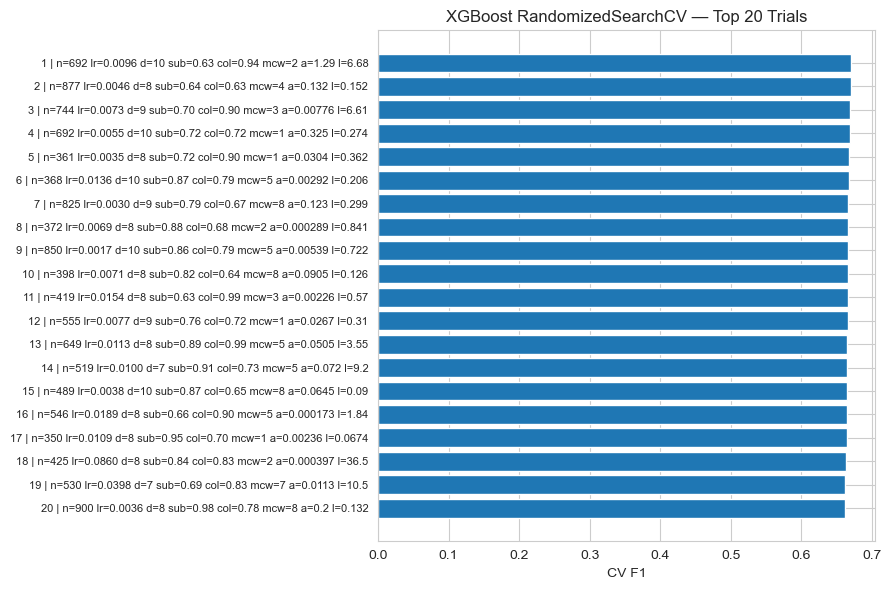

In [26]:
import matplotlib.pyplot as plt

topk = xgb_cvdf.head(20)[::-1]  # reverse for horizontal bar
plt.figure(figsize=(9,6))
plt.barh(range(len(topk)), topk["mean_f1"])
yt = []
for r, p in zip(topk["rank_test_score"], topk.index):
    row = xgb_cvdf.loc[p]
    lab = (f"{int(r)} | "
           f"n={row['param_n_estimators']} "
           f"lr={row['param_learning_rate']:.4f} "
           f"d={row['param_max_depth']} "
           f"sub={row['param_subsample']:.2f} "
           f"col={row['param_colsample_bytree']:.2f} "
           f"mcw={row['param_min_child_weight']} "
           f"a={row['param_reg_alpha']:.3g} "
           f"l={row['param_reg_lambda']:.3g}")
    yt.append(lab)
plt.yticks(range(len(topk)), yt, fontsize=8)
plt.xlabel("CV F1")
plt.title("XGBoost RandomizedSearchCV — Top 20 Trials")
plt.tight_layout(); plt.show()


## Final Comparison: Random Forest vs XGBoost

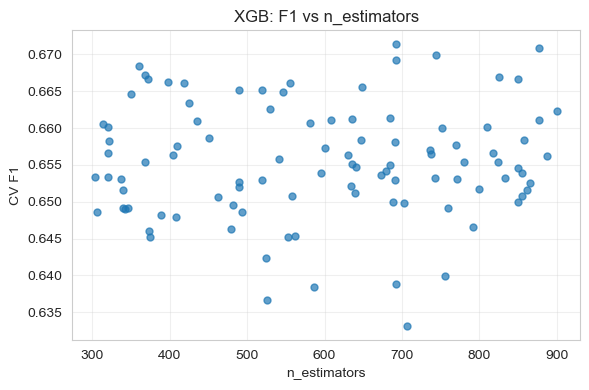

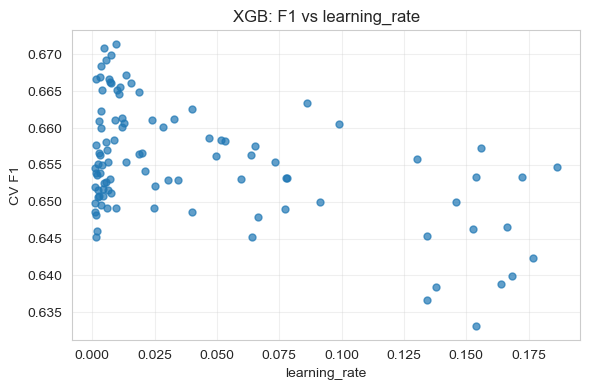

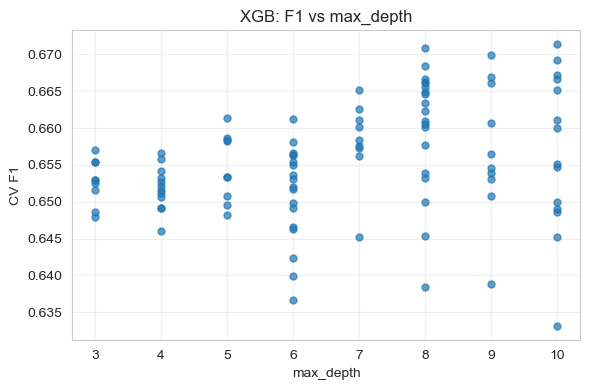

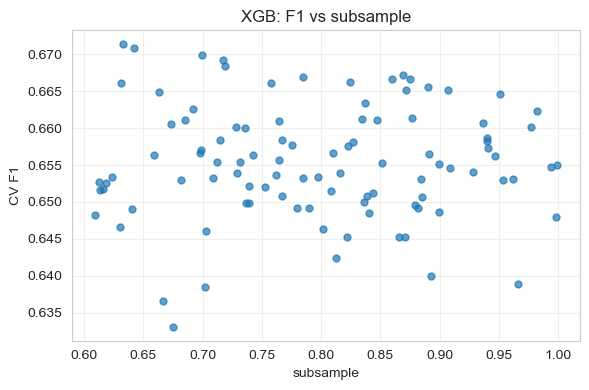

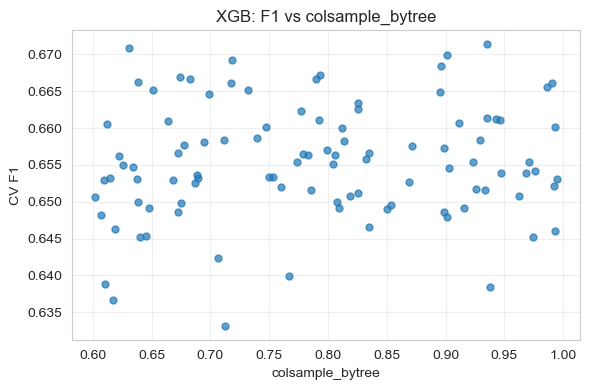

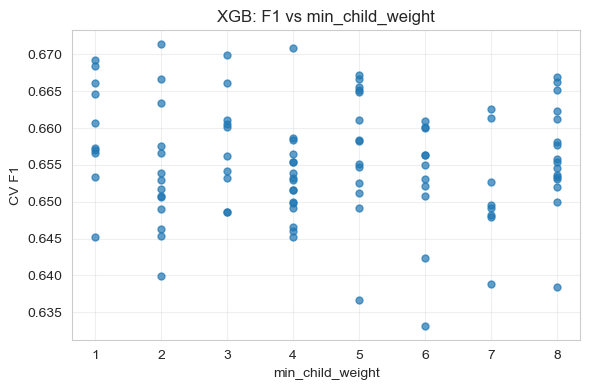

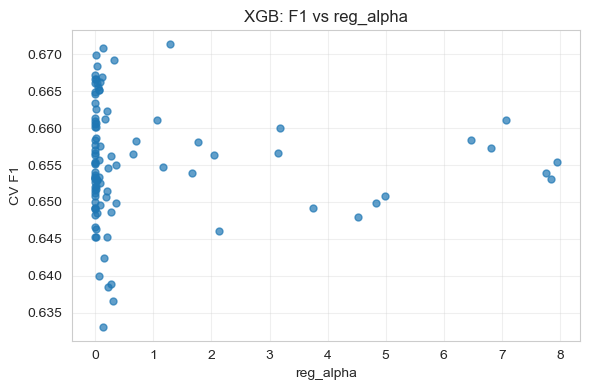

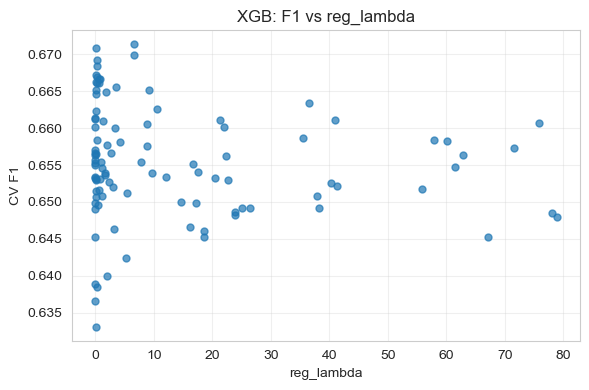

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def scatter_param(param_col, title=None):
    plt.figure(figsize=(6,4))
    x = xgb_cvdf[f"param_{param_col}"]
    y = xgb_cvdf["mean_f1"].values

    # if numeric (int/float), plot directly
    if np.issubdtype(x.dtype, np.number):
        plt.scatter(x, y, s=25, alpha=0.7)
        plt.xlabel(param_col)
    else:
        # categorical fallback
        x_str = x.astype(str)
        cats = {c:i for i,c in enumerate(sorted(x_str.unique()))}
        xs = x_str.map(cats).astype(float).values
        plt.scatter(xs, y, s=25, alpha=0.7)
        plt.xticks(list(cats.values()), list(cats.keys()), rotation=30)
        plt.xlabel(param_col + " (categorical)")
    
    plt.ylabel("CV F1")
    plt.title(title or f"F1 vs {param_col}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

for p in [
    "n_estimators","learning_rate","max_depth","subsample",
    "colsample_bytree","min_child_weight","reg_alpha","reg_lambda"
]:
    scatter_param(p, title=f"XGB: F1 vs {p}")
